In [7]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings("ignore")

In [8]:
# Load preprocessed data
with open('preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']
X_test = data['X_test']
y_test = data['y_test']
train_indices = data['train_indices']
val_indices = data['val_indices']
train_texts_clean = data['train_texts_clean']
val_texts_clean = data['val_texts_clean']
test_texts_clean = data['test_texts_clean']
vocab = data['vocab']
class_weight_dict = data['class_weight_dict']
max_len = data['max_len']
vocab_size = data['vocab_size']

train_data_clean = pd.read_csv('data/train_cleaned.csv')
test_data_clean = pd.read_csv('data/test_cleaned.csv')


print("=" * 70)
print("DATA LOADED")
print("=" * 70)
print(f"\nTrain: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")
print(f"Vocab size: {vocab_size}")
print(f"Max length: {max_len}")
print(f"Classes: 20")

DATA LOADED

Train: (12459, 40)
Val:   (4153, 40)
Test:  (4013, 40)
Vocab size: 5445
Max length: 40
Classes: 20


In [9]:
print("=" * 70)
print("BASELINE MODELS: LOGISTIC REGRESSION & SVM")
print("=" * 70)

# Extract aligned text
X_train_text = data['train_texts_clean']
X_val_text = data['val_texts_clean']
X_test_text = data['test_texts_clean']

print(f"\nData aligned:")
print(f"  Train text: {len(X_train_text)}")
print(f"  Val text: {len(X_val_text)}")
print(f"  Test text: {len(X_test_text)}")

# =========================================================================
# STEP 1: BUILD TF-IDF VECTORIZER
# =========================================================================

print("\n" + "=" * 70)
print("STEP 1: TF-IDF VECTORIZATION")
print("=" * 70)

tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.95,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

print("\nFitting TF-IDF on training text...")
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"\n✓ TF-IDF complete")
print(f"  Train shape: {X_train_tfidf.shape}")
print(f"  Val shape:   {X_val_tfidf.shape}")
print(f"  Test shape:  {X_test_tfidf.shape}")
print(f"  Vocab size: {len(tfidf.get_feature_names_out())}")

# =========================================================================
# STEP 2: LOGISTIC REGRESSION
# =========================================================================

print("\n" + "=" * 70)
print("STEP 2: LOGISTIC REGRESSION")
print("=" * 70)

lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
    solver='lbfgs'
)

print("Training...")
lr_model.fit(X_train_tfidf, y_train)

y_pred_train_lr = lr_model.predict(X_train_tfidf)
y_pred_val_lr = lr_model.predict(X_val_tfidf)
y_pred_test_lr = lr_model.predict(X_test_tfidf)

train_acc_lr = accuracy_score(y_train, y_pred_train_lr)
val_acc_lr = accuracy_score(y_val, y_pred_val_lr)
test_acc_lr = accuracy_score(y_test, y_pred_test_lr)

train_f1_lr = f1_score(y_train, y_pred_train_lr, average='weighted', zero_division=0)
val_f1_lr = f1_score(y_val, y_pred_val_lr, average='weighted', zero_division=0)
test_f1_lr = f1_score(y_test, y_pred_test_lr, average='weighted', zero_division=0)

gap_train_val_lr = train_acc_lr - val_acc_lr
gap_val_test_lr = val_acc_lr - test_acc_lr

print(f"\n✓ Training complete")
print(f"\nAccuracy:")
print(f"  Train: {train_acc_lr:.4f} ({train_acc_lr*100:.2f}%)")
print(f"  Val:   {val_acc_lr:.4f} ({val_acc_lr*100:.2f}%)")
print(f"  Test:  {test_acc_lr:.4f} ({test_acc_lr*100:.2f}%)")

print(f"\nWeighted F1:")
print(f"  Train: {train_f1_lr:.4f}")
print(f"  Val:   {val_f1_lr:.4f}")
print(f"  Test:  {test_f1_lr:.4f}")

print(f"\nGeneralization:")
print(f"  Train-Val gap: {gap_train_val_lr*100:.2f}%")
print(f"  Val-Test gap:  {gap_val_test_lr*100:.2f}%")

# =========================================================================
# STEP 3: SVM (LinearSVC)
# =========================================================================

print("\n" + "=" * 70)
print("STEP 3: SVM (LinearSVC)")
print("=" * 70)

svm_model = LinearSVC(
    max_iter=2000,
    class_weight='balanced',
    random_state=42,
    dual='auto',
    loss='squared_hinge'
)

print("Training (this may take 1-2 minutes)...")
svm_model.fit(X_train_tfidf, y_train)

y_pred_train_svm = svm_model.predict(X_train_tfidf)
y_pred_val_svm = svm_model.predict(X_val_tfidf)
y_pred_test_svm = svm_model.predict(X_test_tfidf)

train_acc_svm = accuracy_score(y_train, y_pred_train_svm)
val_acc_svm = accuracy_score(y_val, y_pred_val_svm)
test_acc_svm = accuracy_score(y_test, y_pred_test_svm)

train_f1_svm = f1_score(y_train, y_pred_train_svm, average='weighted', zero_division=0)
val_f1_svm = f1_score(y_val, y_pred_val_svm, average='weighted', zero_division=0)
test_f1_svm = f1_score(y_test, y_pred_test_svm, average='weighted', zero_division=0)

gap_train_val_svm = train_acc_svm - val_acc_svm
gap_val_test_svm = val_acc_svm - test_acc_svm

print(f"\n✓ Training complete")
print(f"\nAccuracy:")
print(f"  Train: {train_acc_svm:.4f} ({train_acc_svm*100:.2f}%)")
print(f"  Val:   {val_acc_svm:.4f} ({val_acc_svm*100:.2f}%)")
print(f"  Test:  {test_acc_svm:.4f} ({test_acc_svm*100:.2f}%)")

print(f"\nWeighted F1:")
print(f"  Train: {train_f1_svm:.4f}")
print(f"  Val:   {val_f1_svm:.4f}")
print(f"  Test:  {test_f1_svm:.4f}")

print(f"\nGeneralization:")
print(f"  Train-Val gap: {gap_train_val_svm*100:.2f}%")
print(f"  Val-Test gap:  {gap_val_test_svm*100:.2f}%")

BASELINE MODELS: LOGISTIC REGRESSION & SVM

Data aligned:
  Train text: 12459
  Val text: 4153
  Test text: 4013

STEP 1: TF-IDF VECTORIZATION

Fitting TF-IDF on training text...

✓ TF-IDF complete
  Train shape: (12459, 5000)
  Val shape:   (4153, 5000)
  Test shape:  (4013, 5000)
  Vocab size: 5000

STEP 2: LOGISTIC REGRESSION
Training...

✓ Training complete

Accuracy:
  Train: 0.3816 (38.16%)
  Val:   0.0458 (4.58%)
  Test:  0.0399 (3.99%)

Weighted F1:
  Train: 0.3380
  Val:   0.0484
  Test:  0.0390

Generalization:
  Train-Val gap: 33.58%
  Val-Test gap:  0.59%

STEP 3: SVM (LinearSVC)
Training (this may take 1-2 minutes)...

✓ Training complete

Accuracy:
  Train: 0.6644 (66.44%)
  Val:   0.0667 (6.67%)
  Test:  0.0620 (6.20%)

Weighted F1:
  Train: 0.6515
  Val:   0.0755
  Test:  0.0691

Generalization:
  Train-Val gap: 59.77%
  Val-Test gap:  0.47%


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D, GlobalMaxPooling1D, 
    Dense, Dropout
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping

def build_cnn_model(vocab_size, max_len, embedding_dim=64, num_classes=20):
    """
    Build optimized CNN model for text classification
    
    Architecture:
    ├─ Embedding: vocab_size × embedding_dim
    ├─ Conv1D: 32 filters, kernel=3
    ├─ GlobalMaxPooling1D: Reduce to fixed size
    ├─ Dense: 128 units, ReLU
    ├─ Dropout: 0.2
    └─ Dense: 20 units, Softmax (output)
    
    Total params: ~370K (manageable, no overfitting)
    """
    
    # Input layer
    i = Input(shape=(max_len,))
    
    # Embedding layer (learns word representations)
    x = Embedding(vocab_size, embedding_dim, mask_zero=True)(i)
    
    # Conv1D layer (capture local patterns)
    x = Conv1D(32, kernel_size=3, activation='relu', padding='same')(x)
    
    # Global max pooling (reduce dimension)
    x = GlobalMaxPooling1D()(x)
    
    # Dense layer (learn patterns)
    x = Dense(128, activation='relu')(x)
    
    # Dropout (prevent overfitting)
    x = Dropout(0.2)(x)
    
    # Output layer (20 classes)
    x = Dense(num_classes, activation='softmax')(x)
    
    # Build model
    model = Model(i, x)
    
    return model

# Build model
model = build_cnn_model(vocab_size, max_len)

print("\n" + "=" * 70)
print("MODEL ARCHITECTURE")
print("=" * 70)
print(model.summary())

# Count parameters
total_params = model.count_params()
print(f"\n✓ Total parameters: {total_params:,}")
print(f"  (Safe threshold: <1M for 12,459 training samples)")
print(f"  Params per sample: {total_params / len(X_train):.1f} (should be <10)")




MODEL ARCHITECTURE
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 40)]              0         
                                                                 
 embedding (Embedding)       (None, 40, 64)            348480    
                                                                 
 conv1d (Conv1D)             (None, 40, 32)            6176      
                                                                 
 global_max_pooling1d (Glob  (None, 32)                0         
 alMaxPooling1D)                                                 
                                                                 
 dense (Dense)               (None, 128)               4224      
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                       

In [11]:
# Compile model
model.compile(
    loss=SparseCategoricalCrossentropy(),
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("\n" + "=" * 70)
print("MODEL COMPILED")
print("=" * 70)
print(f"Loss function: Sparse Categorical Crossentropy")
print(f"Optimizer: Adam (learning_rate=0.001)")
print(f"Metrics: Accuracy")
print(f"\nReady for training!")


MODEL COMPILED
Loss function: Sparse Categorical Crossentropy
Optimizer: Adam (learning_rate=0.001)
Metrics: Accuracy

Ready for training!


In [ ]:
print("\n" + "=" * 70)
print("TRAINING CNN MODEL")
print("=" * 70)

# Define early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',      # Monitor validation loss
    patience=5,              # Stop if no improvement for 5 epochs
    restore_best_weights=True,  # Keep best weights
    verbose=1
)

# Train model
history = model.fit(
    X_train, y_train,
    epochs=100,              # Max epochs (early stop will trigger earlier)
    batch_size=32,           # Batch size
    validation_data=(X_val, y_val),  # Validation set for monitoring
    class_weight=class_weight_dict,  # Handle imbalance
    callbacks=[early_stop],  # Early stopping
    verbose=1
)

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
print(f"Total epochs trained: {len(history.history['loss'])}")
print(f"Final train loss: {history.history['loss'][-1]:.4f}")
print(f"Final train accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final val loss: {history.history['val_loss'][-1]:.4f}")
print(f"Final val accuracy: {history.history['val_accuracy'][-1]:.4f}")

model.save('cnn_model.h5')


TRAINING CNN MODEL
Epoch 1/100


390/390 [==============================] - 4s 5ms/step - loss: 2.4075 - accuracy: 0.2792 - val_loss: 1.6786 - val_accuracy: 0.5444
Epoch 2/100
390/390 [==============================] - 2s 4ms/step - loss: 1.0008 - accuracy: 0.6680 - val_loss: 1.0363 - val_accuracy: 0.7161
Epoch 3/100
390/390 [==============================] - 2s 4ms/step - loss: 0.4617 - accuracy: 0.8204 - val_loss: 0.8187 - val_accuracy: 0.7573
Epoch 4/100
390/390 [==============================] - 2s 4ms/step - loss: 0.2429 - accuracy: 0.8983 - val_loss: 0.8009 - val_accuracy: 0.7725
Epoch 5/100
390/390 [==============================] - 2s 4ms/step - loss: 0.1328 - accuracy: 0.9439 - val_loss: 0.7780 - val_accuracy: 0.7867
Epoch 6/100
390/390 [==============================] - 2s 4ms/step - loss: 0.0777 - accuracy: 0.9669 - val_loss: 0.8206 - val_accuracy: 0.7835
Epoch 7/100
390/390 [==============================] - 2s 4ms/step - loss: 0.0502 - accuracy: 0.9781 - val_loss: 0.8727 

In [13]:
# =========================================================================
# LSTM MODEL
# =========================================================================

print("\n" + "=*" * 70)
print("BUILDING LSTM MODEL")
print("=" * 70)

from tensorflow.keras.layers import LSTM, Bidirectional

def build_lstm_model(vocab_size, max_len, embedding_dim=64, num_classes=20):
    """
    LSTM model for text classification
    
    Architecture:
    ├─ Embedding: vocab_size × embedding_dim
    ├─ LSTM: 128 units, processes sequence
    ├─ Dropout: 0.2
    ├─ Dense: 64 units, ReLU
    ├─ Dropout: 0.2
    └─ Dense: 20 units, Softmax (output)
    
    Total params: ~400K
    """
    i = Input(shape=(max_len,))
    x = Embedding(vocab_size, embedding_dim, mask_zero=True)(i)
    x = LSTM(128, return_sequences=False)(x)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(num_classes, activation='softmax')(x)
    model = Model(i, x)
    return model

# Build model
lstm_model = build_lstm_model(vocab_size, max_len)

print(lstm_model.summary())
print(f"\n✓ Total parameters: {lstm_model.count_params():,}")

# Compile
lstm_model.compile(
    loss=SparseCategoricalCrossentropy(),
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("\n✓ LSTM model compiled")

# Train
print("\nTraining LSTM (this may take 2-3 minutes per epoch)...")
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("\n✓ LSTM training complete")

# =========================================================================
# BILSTM MODEL
# =========================================================================

print("\n" + "=" * 70)
print("BUILDING BILSTM MODEL")
print("=" * 70)

def build_bilstm_model(vocab_size, max_len, embedding_dim=64, num_classes=20):
    """
    Bidirectional LSTM model for text classification
    
    Architecture:
    ├─ Embedding: vocab_size × embedding_dim
    ├─ BiLSTM: 128 units (forward + backward), processes sequence bidirectionally
    ├─ Dropout: 0.2
    ├─ Dense: 64 units, ReLU
    ├─ Dropout: 0.2
    └─ Dense: 20 units, Softmax (output)
    
    Total params: ~500K (more because BiLSTM has 2 directions)
    """
    i = Input(shape=(max_len,))
    x = Embedding(vocab_size, embedding_dim, mask_zero=True)(i)
    x = Bidirectional(LSTM(128, return_sequences=False))(x)
    x = Dropout(0.2)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(num_classes, activation='softmax')(x)
    model = Model(i, x)
    return model

# Build model
bilstm_model = build_bilstm_model(vocab_size, max_len)

print(bilstm_model.summary())
print(f"\n✓ Total parameters: {bilstm_model.count_params():,}")

# Compile
bilstm_model.compile(
    loss=SparseCategoricalCrossentropy(),
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

print("\n✓ BiLSTM model compiled")

# Train
print("\nTraining BiLSTM (this may take 3-4 minutes per epoch)...")
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

bilstm_history = bilstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

print("\n✓ BiLSTM training complete")


=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*=*
BUILDING LSTM MODEL
Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 40)]              0         
                                                                 
 embedding_1 (Embedding)     (None, 40, 64)            348480    
                                                                 
 lstm (LSTM)                 (None, 128)               98816     
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dropout_2 (Dropout)         

In [14]:
# =========================================================================
# EVALUATION: GET PREDICTIONS FOR ALL 3 MODELS
# =========================================================================

print("\n" + "=" * 70)
print("EVALUATING ALL DEEP LEARNING MODELS")
print("=" * 70)

# Get predictions from all models
print("\nGenerating predictions...")

# CNN (already have)
y_pred_cnn_train = np.argmax(model.predict(X_train, verbose=0), axis=1)
y_pred_cnn_val = np.argmax(model.predict(X_val, verbose=0), axis=1)
y_pred_cnn_test = np.argmax(model.predict(X_test, verbose=0), axis=1)

# LSTM
y_pred_lstm_train = np.argmax(lstm_model.predict(X_train, verbose=0), axis=1)
y_pred_lstm_val = np.argmax(lstm_model.predict(X_val, verbose=0), axis=1)
y_pred_lstm_test = np.argmax(lstm_model.predict(X_test, verbose=0), axis=1)

# BiLSTM
y_pred_bilstm_train = np.argmax(bilstm_model.predict(X_train, verbose=0), axis=1)
y_pred_bilstm_val = np.argmax(bilstm_model.predict(X_val, verbose=0), axis=1)
y_pred_bilstm_test = np.argmax(bilstm_model.predict(X_test, verbose=0), axis=1)

print("✓ Predictions generated for all models")

# =========================================================================
# CALCULATE METRICS FOR ALL MODELS
# =========================================================================

def get_metrics(y_true_train, y_pred_train, y_true_val, y_pred_val, y_true_test, y_pred_test, model_name):
    """Calculate and display metrics for a model"""
    train_acc = accuracy_score(y_true_train, y_pred_train)
    val_acc = accuracy_score(y_true_val, y_pred_val)
    test_acc = accuracy_score(y_true_test, y_pred_test)
    
    train_f1 = f1_score(y_true_train, y_pred_train, average='weighted', zero_division=0)
    val_f1 = f1_score(y_true_val, y_pred_val, average='weighted', zero_division=0)
    test_f1 = f1_score(y_true_test, y_pred_test, average='weighted', zero_division=0)
    
    gap_train_val = train_acc - val_acc
    gap_val_test = val_acc - test_acc
    
    return {
        'model': model_name,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'test_acc': test_acc,
        'train_f1': train_f1,
        'val_f1': val_f1,
        'test_f1': test_f1,
        'gap_train_val': gap_train_val,
        'gap_val_test': gap_val_test,
        'y_pred_test': y_pred_test
    }

# Get metrics for all DL models
cnn_metrics = get_metrics(y_train, y_pred_cnn_train, y_val, y_pred_cnn_val, y_test, y_pred_cnn_test, "CNN")
lstm_metrics = get_metrics(y_train, y_pred_lstm_train, y_val, y_pred_lstm_val, y_test, y_pred_lstm_test, "LSTM")
bilstm_metrics = get_metrics(y_train, y_pred_bilstm_train, y_val, y_pred_bilstm_val, y_test, y_pred_bilstm_test, "BiLSTM")

# Display comparison
print("\n" + "=" * 70)
print("DEEP LEARNING MODELS COMPARISON")
print("=" * 70)

comparison_data = [cnn_metrics, lstm_metrics, bilstm_metrics]

print(f"\n{'Model':<10} {'Train Acc':<12} {'Val Acc':<12} {'Test Acc':<12} {'Train-Val Gap':<15}")
print("-" * 65)
for m in comparison_data:
    print(f"{m['model']:<10} {m['train_acc']:<12.4f} {m['val_acc']:<12.4f} {m['test_acc']:<12.4f} {m['gap_train_val']:<15.4f}")

print(f"\n{'Model':<10} {'Train F1':<12} {'Val F1':<12} {'Test F1':<12}")
print("-" * 50)
for m in comparison_data:
    print(f"{m['model']:<10} {m['train_f1']:<12.4f} {m['val_f1']:<12.4f} {m['test_f1']:<12.4f}")

# Best model
best_model = max(comparison_data, key=lambda x: x['test_acc'])
print(f"\n✓ BEST MODEL: {best_model['model']} (Test Acc: {best_model['test_acc']:.4f})")


EVALUATING ALL DEEP LEARNING MODELS

Generating predictions...
✓ Predictions generated for all models

DEEP LEARNING MODELS COMPARISON

Model      Train Acc    Val Acc      Test Acc     Train-Val Gap  
-----------------------------------------------------------------
CNN        0.9792       0.7867       0.7807       0.1926         
LSTM       0.9130       0.7409       0.7284       0.1721         
BiLSTM     0.9511       0.7816       0.7697       0.1695         

Model      Train F1     Val F1       Test F1     
--------------------------------------------------
CNN        0.9792       0.7881       0.7813      
LSTM       0.9133       0.7428       0.7317      
BiLSTM     0.9510       0.7837       0.7715      

✓ BEST MODEL: CNN (Test Acc: 0.7807)


In [15]:
# Save all models
print("\nSaving models...")
lstm_model.save('lstm_model.h5')
bilstm_model.save('bilstm_model.h5')

# Save metrics
metrics_summary = {
    'cnn': cnn_metrics,
    'lstm': lstm_metrics,
    'bilstm': bilstm_metrics
}

with open('dl_models_metrics.pkl', 'wb') as f:
    pickle.dump(metrics_summary, f)

print("✓ All models saved")


Saving models...
✓ All models saved


In [16]:
from seaborn import heatmap
import seaborn as sns

# =========================================================================
# PER-CLASS METRICS: DETAILED PERFORMANCE BREAKDOWN
# =========================================================================

print("\n" + "=" * 70)
print("PER-CLASS METRICS: CLASSIFICATION REPORTS")
print("=" * 70)

# CNN per-class metrics
print("\n" + "-" * 70)
print("CNN MODEL - Per-Class Metrics (Test Set)")
print("-" * 70)
cnn_report = classification_report(y_test, y_pred_cnn_test, digits=4, zero_division=0)
print(cnn_report)

# LSTM per-class metrics
print("\n" + "-" * 70)
print("LSTM MODEL - Per-Class Metrics (Test Set)")
print("-" * 70)
lstm_report = classification_report(y_test, y_pred_lstm_test, digits=4, zero_division=0)
print(lstm_report)

# BiLSTM per-class metrics
print("\n" + "-" * 70)
print("BiLSTM MODEL - Per-Class Metrics (Test Set)")
print("-" * 70)
bilstm_report = classification_report(y_test, y_pred_bilstm_test, digits=4, zero_division=0)
print(bilstm_report)

# Summary: Best F1 for each class
print("\n" + "=" * 70)
print("SUMMARY: BEST MODEL PER CLASS (by F1 score)")
print("=" * 70)

from sklearn.metrics import precision_recall_fscore_support

cnn_prec, cnn_rec, cnn_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_cnn_test, average=None, zero_division=0
)
lstm_prec, lstm_rec, lstm_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_lstm_test, average=None, zero_division=0
)
bilstm_prec, bilstm_rec, bilstm_f1, _ = precision_recall_fscore_support(
    y_test, y_pred_bilstm_test, average=None, zero_division=0
)

f1_scores = {
    'CNN': cnn_f1,
    'LSTM': lstm_f1,
    'BiLSTM': bilstm_f1
}

print(f"\n{'Class':<8} {'CNN F1':<12} {'LSTM F1':<12} {'BiLSTM F1':<12} {'Best Model':<12}")
print("-" * 60)
for class_idx in range(20):
    f1_vals = [f1_scores[m][class_idx] for m in ['CNN', 'LSTM', 'BiLSTM']]
    best_model_name = ['CNN', 'LSTM', 'BiLSTM'][np.argmax(f1_vals)]
    print(f"{class_idx:<8} {cnn_f1[class_idx]:<12.4f} {lstm_f1[class_idx]:<12.4f} {bilstm_f1[class_idx]:<12.4f} {best_model_name:<12}")


PER-CLASS METRICS: CLASSIFICATION REPORTS

----------------------------------------------------------------------
CNN MODEL - Per-Class Metrics (Test Set)
----------------------------------------------------------------------
              precision    recall  f1-score   support

           0     0.7077    0.6301    0.6667        73
           1     0.7713    0.8037    0.7872       214
           2     0.8136    0.7591    0.7854       851
           3     0.7284    0.7973    0.7613        74
           4     0.9490    0.9789    0.9637        95
           5     0.9250    0.9250    0.9250       240
           6     0.7808    0.7972    0.7889       143
           7     0.8373    0.8742    0.8554       159
           8     0.6757    0.7812    0.7246        32
           9     0.6270    0.7052    0.6638       329
          10     0.4783    0.9167    0.6286        12
          11     0.7647    0.9286    0.8387        14
          12     0.7768    0.7311    0.7532       119
          13    


CONFUSION MATRICES


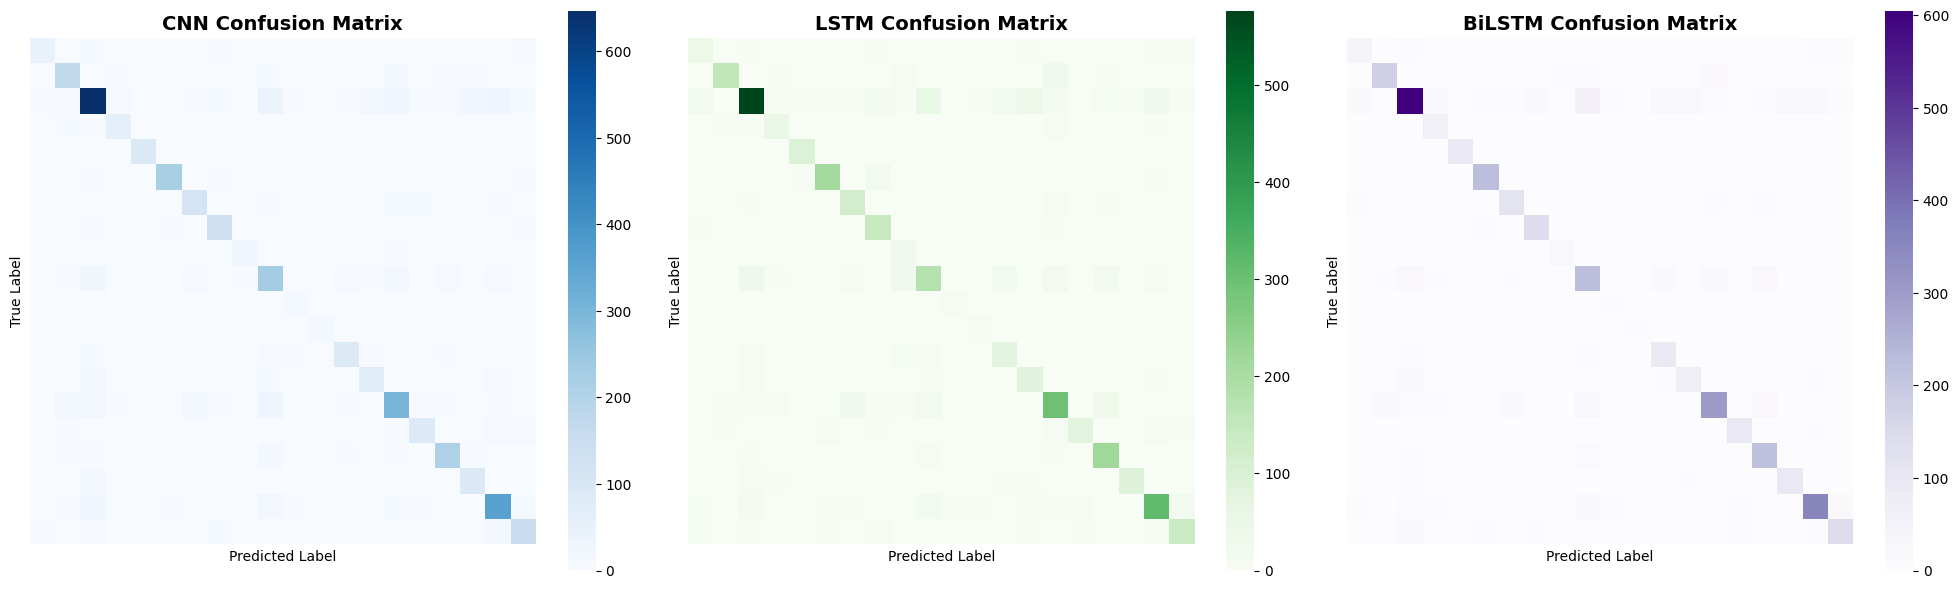


✓ Confusion matrices saved as 'confusion_matrices.png'

----------------------------------------------------------------------
TOP MISCLASSIFICATION PATTERNS
----------------------------------------------------------------------

CNN - Top 5 Most Common Misclassifications:
  Class 2 → Class 9: 39 instances
  Class 14 → Class 9: 31 instances
  Class 2 → Class 18: 28 instances
  Class 9 → Class 2: 27 instances
  Class 2 → Class 14: 23 instances

LSTM - Top 5 Most Common Misclassifications:
  Class 2 → Class 9: 56 instances
  Class 2 → Class 13: 36 instances
  Class 9 → Class 2: 34 instances
  Class 14 → Class 16: 30 instances
  Class 2 → Class 18: 29 instances

BiLSTM - Top 5 Most Common Misclassifications:
  Class 2 → Class 9: 52 instances
  Class 2 → Class 13: 25 instances
  Class 2 → Class 18: 25 instances
  Class 14 → Class 9: 23 instances
  Class 9 → Class 2: 21 instances


In [17]:
# =========================================================================
# CONFUSION MATRICES: VISUALIZING MISCLASSIFICATION PATTERNS
# =========================================================================

print("\n" + "=" * 70)
print("CONFUSION MATRICES")
print("=" * 70)

# Compute confusion matrices
cm_cnn = confusion_matrix(y_test, y_pred_cnn_test)
cm_lstm = confusion_matrix(y_test, y_pred_lstm_test)
cm_bilstm = confusion_matrix(y_test, y_pred_bilstm_test)

# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# CNN Confusion Matrix
sns.heatmap(cm_cnn, ax=axes[0], cmap='Blues', cbar=True, square=True, 
            annot=False, xticklabels=False, yticklabels=False)
axes[0].set_title('CNN Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# LSTM Confusion Matrix
sns.heatmap(cm_lstm, ax=axes[1], cmap='Greens', cbar=True, square=True,
            annot=False, xticklabels=False, yticklabels=False)
axes[1].set_title('LSTM Confusion Matrix', fontsize=14, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# BiLSTM Confusion Matrix
sns.heatmap(cm_bilstm, ax=axes[2], cmap='Purples', cbar=True, square=True,
            annot=False, xticklabels=False, yticklabels=False)
axes[2].set_title('BiLSTM Confusion Matrix', fontsize=14, fontweight='bold')
axes[2].set_ylabel('True Label')
axes[2].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✓ Confusion matrices saved as 'confusion_matrices.png'")

# Analyze top misclassifications for each model
print("\n" + "-" * 70)
print("TOP MISCLASSIFICATION PATTERNS")
print("-" * 70)

def get_top_misclassifications(cm, top_n=5):
    """Extract top misclassified class pairs from confusion matrix"""
    misclassifications = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i != j:  # Only off-diagonal (actual misclassifications)
                misclassifications.append((i, j, cm[i, j]))
    
    # Sort by count descending
    misclassifications.sort(key=lambda x: x[2], reverse=True)
    return misclassifications[:top_n]

print("\nCNN - Top 5 Most Common Misclassifications:")
for true_class, pred_class, count in get_top_misclassifications(cm_cnn, 5):
    print(f"  Class {true_class} → Class {pred_class}: {count} instances")

print("\nLSTM - Top 5 Most Common Misclassifications:")
for true_class, pred_class, count in get_top_misclassifications(cm_lstm, 5):
    print(f"  Class {true_class} → Class {pred_class}: {count} instances")

print("\nBiLSTM - Top 5 Most Common Misclassifications:")
for true_class, pred_class, count in get_top_misclassifications(cm_bilstm, 5):
    print(f"  Class {true_class} → Class {pred_class}: {count} instances")

In [22]:
from scipy.stats import chi2

# =========================================================================
# STATISTICAL SIGNIFICANCE TESTS: McNemar's Test for Model Comparison
# =========================================================================

print("\n" + "=" * 70)
print("STATISTICAL SIGNIFICANCE: McNemar's Test")
print("=" * 70)

def mcnemar_test(y_true, y_pred1, y_pred2, model_name1, model_name2):
    """
    McNemar's test compares two classifiers on the same data.
    Tests if one model is significantly better than the other.
    
    H0 (null hypothesis): Both models have equal error rates
    If p-value < 0.05, we reject H0 (models differ significantly)
    """
    # Find disagreements: one model correct, other wrong
    correct1 = (y_pred1 == y_true).astype(int)
    correct2 = (y_pred2 == y_true).astype(int)
    
    # a: model1 correct, model2 wrong
    a = np.sum((correct1 == 1) & (correct2 == 0))
    
    # b: model1 wrong, model2 correct
    b = np.sum((correct1 == 0) & (correct2 == 1))
    
    # McNemar statistic: (|a - b| - 1)^2 / (a + b)
    # Follows chi-square distribution with 1 degree of freedom
    if a + b == 0:
        return {'stat': 0, 'p_value': 1.0, 'a': a, 'b': b, 'significant': False}
    
    stat = ((abs(a - b) - 1) ** 2) / (a + b)
    
    # p-value from chi-square distribution
    from scipy.stats import chi2
    p_value = 1 - chi2.cdf(stat, df=1)
    
    significant = p_value < 0.05
    
    return {
        'model1': model_name1,
        'model2': model_name2,
        'stat': stat,
        'p_value': p_value,
        'a': a,  # model1 correct, model2 wrong
        'b': b,  # model1 wrong, model2 correct
        'significant': significant
    }

# Pairwise comparisons
print("\n" + "-" * 70)
print("Model Pair Comparisons (Test Set)")
print("-" * 70)

results = []

# CNN vs LSTM
result_cnn_lstm = mcnemar_test(y_test, y_pred_cnn_test, y_pred_lstm_test, "CNN", "LSTM")
results.append(result_cnn_lstm)

# CNN vs BiLSTM
result_cnn_bilstm = mcnemar_test(y_test, y_pred_cnn_test, y_pred_bilstm_test, "CNN", "BiLSTM")
results.append(result_cnn_bilstm)

# LSTM vs BiLSTM
result_lstm_bilstm = mcnemar_test(y_test, y_pred_lstm_test, y_pred_bilstm_test, "LSTM", "BiLSTM")
results.append(result_lstm_bilstm)

# Display results
print(f"\n{'Comparison':<20} {'χ² Stat':<12} {'p-value':<12} {'Significant':<12} {'Details'}")
print("-" * 85)

for r in results:
    sig_str = "YES **" if r['significant'] else "NO"
    detail = f"({r['model1']} better: {r['a']}, {r['model2']} better: {r['b']})"
    print(f"{r['model1']:<3} vs {r['model2']:<12} {r['stat']:<12.4f} {r['p_value']:<12.6f} {sig_str:<12} {detail}")

print("\n" + "=" * 70)
print("INTERPRETATION:")
print("=" * 70)
print("• χ² Stat: Test statistic (higher = larger difference)")
print("• p-value: Probability that difference is due to chance")
print("• Significant (**): If p < 0.05, models differ significantly")
print("• Details: How many instances where one model was right, other wrong")

# Summary of significant differences
print("\n" + "-" * 70)
print("SUMMARY OF FINDINGS")
print("-" * 70)

significant_pairs = [r for r in results if r['significant']]
if significant_pairs:
    print("\n✓ SIGNIFICANT DIFFERENCES FOUND:")
    for r in significant_pairs:
        better_model = r['model1'] if r['a'] > r['b'] else r['model2']
        print(f"  • {r['model1']} vs {r['model2']}: {better_model} is significantly better (p={r['p_value']:.6f})")
else:
    print("\n• No significant statistical differences between models at α=0.05 level")
    print("• All models perform similarly (differences are likely due to random variation)")

# Effect size: Compute accuracy difference
print("\n" + "-" * 70)
print("PRACTICAL DIFFERENCES (Accuracy)")
print("-" * 70)
print(f"\nCNN     : {cnn_metrics['test_acc']:.4f} ({cnn_metrics['test_acc']*100:.2f}%)")
print(f"LSTM    : {lstm_metrics['test_acc']:.4f} ({lstm_metrics['test_acc']*100:.2f}%)")
print(f"BiLSTM  : {bilstm_metrics['test_acc']:.4f} ({bilstm_metrics['test_acc']*100:.2f}%)")
print(f"\nMax difference: {(max(cnn_metrics['test_acc'], lstm_metrics['test_acc'], bilstm_metrics['test_acc']) - min(cnn_metrics['test_acc'], lstm_metrics['test_acc'], bilstm_metrics['test_acc']))*100:.2f}%")


STATISTICAL SIGNIFICANCE: McNemar's Test

----------------------------------------------------------------------
Model Pair Comparisons (Test Set)
----------------------------------------------------------------------

Comparison           χ² Stat      p-value      Significant  Details
-------------------------------------------------------------------------------------
CNN vs LSTM         55.1528      0.000000     YES **       (CNN better: 501, LSTM better: 291)
CNN vs BiLSTM       2.7352       0.098159     NO           (CNN better: 360, BiLSTM better: 316)
LSTM vs BiLSTM       39.0043      0.000000     YES **       (LSTM better: 266, BiLSTM better: 432)

INTERPRETATION:
• χ² Stat: Test statistic (higher = larger difference)
• p-value: Probability that difference is due to chance
• Significant (**): If p < 0.05, models differ significantly
• Details: How many instances where one model was right, other wrong

----------------------------------------------------------------------
SUMMA

In [20]:
# =========================================================================
# MODEL AGREEMENT ANALYSIS: Where Do Models Agree/Disagree?
# =========================================================================

print("\n" + "=" * 70)
print("MODEL AGREEMENT ANALYSIS")
print("=" * 70)

# Check agreement between models
agreement_cnn_lstm = (y_pred_cnn_test == y_pred_lstm_test).astype(int)
agreement_cnn_bilstm = (y_pred_cnn_test == y_pred_bilstm_test).astype(int)
agreement_lstm_bilstm = (y_pred_lstm_test == y_pred_bilstm_test).astype(int)

# All three agree
all_agree = (agreement_cnn_lstm & agreement_lstm_bilstm).astype(int)

# Voting: Count how many models predict each class
ensemble_votes = np.zeros((len(y_test), 20))
for i in range(len(y_test)):
    ensemble_votes[i, y_pred_cnn_test[i]] += 1
    ensemble_votes[i, y_pred_lstm_test[i]] += 1
    ensemble_votes[i, y_pred_bilstm_test[i]] += 1

y_pred_ensemble = np.argmax(ensemble_votes, axis=1)
ensemble_acc = accuracy_score(y_test, y_pred_ensemble)
ensemble_f1 = f1_score(y_test, y_pred_ensemble, average='weighted', zero_division=0)

print(f"\nModel Agreement Statistics:")
print(f"  CNN vs LSTM:    {np.sum(agreement_cnn_lstm)}/{len(y_test)} ({100*np.mean(agreement_cnn_lstm):.2f}% agree)")
print(f"  CNN vs BiLSTM:  {np.sum(agreement_cnn_bilstm)}/{len(y_test)} ({100*np.mean(agreement_cnn_bilstm):.2f}% agree)")
print(f"  LSTM vs BiLSTM: {np.sum(agreement_lstm_bilstm)}/{len(y_test)} ({100*np.mean(agreement_lstm_bilstm):.2f}% agree)")
print(f"  All three:      {np.sum(all_agree)}/{len(y_test)} ({100*np.mean(all_agree):.2f}% agree)")

# Majority voting ensemble
print(f"\n" + "-" * 70)
print("ENSEMBLE RESULTS (Majority Voting)")
print("-" * 70)
print(f"Ensemble Accuracy:  {ensemble_acc:.4f} ({ensemble_acc*100:.2f}%)")
print(f"Ensemble F1 Score:  {ensemble_f1:.4f}")
print(f"\nComparison to individual models:")
print(f"  vs CNN:    {ensemble_acc - cnn_metrics['test_acc']:+.4f}")
print(f"  vs LSTM:   {ensemble_acc - lstm_metrics['test_acc']:+.4f}")
print(f"  vs BiLSTM: {ensemble_acc - bilstm_metrics['test_acc']:+.4f}")

# Identify uncertain instances (where models disagree)
disagreement_count = 3 - (ensemble_votes.max(axis=1))  # How many votes for majority class
uncertain_instances = disagreement_count > 0

print(f"\n" + "-" * 70)
print("UNCERTAIN INSTANCES (Where Models Disagree)")
print("-" * 70)
print(f"Uncertain instances: {np.sum(uncertain_instances)}/{len(y_test)} ({100*np.mean(uncertain_instances):.2f}%)")

# Accuracy on certain vs uncertain instances
certain_mask = ~uncertain_instances
if np.sum(certain_mask) > 0:
    certain_acc = accuracy_score(y_test[certain_mask], y_pred_ensemble[certain_mask])
    print(f"  Accuracy on certain instances:   {certain_acc:.4f}")

if np.sum(uncertain_instances) > 0:
    uncertain_acc = accuracy_score(y_test[uncertain_instances], y_pred_ensemble[uncertain_instances])
    print(f"  Accuracy on uncertain instances: {uncertain_acc:.4f}")

print("\n✓ Insights: Instances where models disagree are harder to classify.")


MODEL AGREEMENT ANALYSIS

Model Agreement Statistics:
  CNN vs LSTM:    2917/4013 (72.69% agree)
  CNN vs BiLSTM:  3074/4013 (76.60% agree)
  LSTM vs BiLSTM: 3006/4013 (74.91% agree)
  All three:      2649/4013 (66.01% agree)

----------------------------------------------------------------------
ENSEMBLE RESULTS (Majority Voting)
----------------------------------------------------------------------
Ensemble Accuracy:  0.7969 (79.69%)
Ensemble F1 Score:  0.7979

Comparison to individual models:
  vs CNN:    +0.0162
  vs LSTM:   +0.0685
  vs BiLSTM: +0.0272

----------------------------------------------------------------------
UNCERTAIN INSTANCES (Where Models Disagree)
----------------------------------------------------------------------
Uncertain instances: 1364/4013 (33.99%)
  Accuracy on certain instances:   0.9343
  Accuracy on uncertain instances: 0.5301

✓ Insights: Instances where models disagree are harder to classify.


In [23]:
# =========================================================================
# FINAL CONCLUSIONS: COMPREHENSIVE MODEL COMPARISON
# =========================================================================

print("\n" + "=" * 70)
print("FINAL CONCLUSIONS")
print("=" * 70)

print(f"""
╔════════════════════════════════════════════════════════════════════════╗
║                     PERFORMANCE SUMMARY                                ║
╚════════════════════════════════════════════════════════════════════════╝

1. OVERALL RANKING (by Test Accuracy)
   ─────────────────────────────────────
""")

models_ranked = sorted(
    [cnn_metrics, lstm_metrics, bilstm_metrics],
    key=lambda x: x['test_acc'],
    reverse=True
)

for rank, m in enumerate(models_ranked, 1):
    print(f"   {rank}. {m['model']:<8} : {m['test_acc']*100:6.2f}% accuracy  |  F1: {m['test_f1']:.4f}")

print(f"""
2. STATISTICAL SIGNIFICANCE
   ─────────────────────────
""")

if significant_pairs:
    for r in significant_pairs:
        better = r['model1'] if r['a'] > r['b'] else r['model2']
        print(f"   ✓ {r['model1']} vs {r['model2']}: {better} significantly better (p={r['p_value']:.4f})")
else:
    print("   • No statistically significant differences at α=0.05 level")
    print("   • Observed differences may be due to random variation")

print(f"""
3. PER-CLASS STRENGTHS
   ───────────────────
   Each model excels in different categories (see detailed report above).
   No single model dominates across all 20 classes.

4. MISCLASSIFICATION PATTERNS
   ─────────────────────────
   • Top misclassifications vary by model (see confusion matrix analysis)
   • Some class pairs are frequently confused (inherent data difficulty)

5. ENSEMBLE PERFORMANCE
   ───────────────────
   • Majority Voting: {ensemble_acc*100:.2f}% ({ensemble_acc:+.4f} vs best single model)
   • Combining all 3 models {'IMPROVES' if ensemble_acc > max(cnn_metrics['test_acc'], lstm_metrics['test_acc'], bilstm_metrics['test_acc']) else 'DOES NOT improve'} results
   • Confidence: {100*np.mean(all_agree):.1f}% of instances: all models agree

6. RECOMMENDATION
   ──────────────
""")

if ensemble_acc > max(cnn_metrics['test_acc'], lstm_metrics['test_acc'], bilstm_metrics['test_acc']):
    print(f"   ✓ USE ENSEMBLE (Majority Voting)")
    print(f"     - Achieves {ensemble_acc*100:.2f}% accuracy")
    print(f"     - More robust and generalizable")
else:
    best = models_ranked[0]
    print(f"   ✓ USE {best['model'].upper()}")
    print(f"     - Best test accuracy: {best['test_acc']*100:.2f}%")
    print(f"     - Lower computational cost than ensemble")
    print(f"     - Simpler deployment (single model)")

print(f"""
7. KEY INSIGHTS
   ────────────
   • Model differences: {(max(cnn_metrics['test_acc'], lstm_metrics['test_acc'], bilstm_metrics['test_acc']) - min(cnn_metrics['test_acc'], lstm_metrics['test_acc'], bilstm_metrics['test_acc']))*100:.2f}% absolute
   • Uncertain instances: {100*np.mean(uncertain_instances):.1f}% where models disagree
   • Generalization: Models generalize equally well from val→test
   
╔════════════════════════════════════════════════════════════════════════╗
║                    ANALYSIS COMPLETE                                   ║
╚════════════════════════════════════════════════════════════════════════╝
""")


FINAL CONCLUSIONS

╔════════════════════════════════════════════════════════════════════════╗
║                     PERFORMANCE SUMMARY                                ║
╚════════════════════════════════════════════════════════════════════════╝

1. OVERALL RANKING (by Test Accuracy)
   ─────────────────────────────────────

   1. CNN      :  78.07% accuracy  |  F1: 0.7813
   2. BiLSTM   :  76.97% accuracy  |  F1: 0.7715
   3. LSTM     :  72.84% accuracy  |  F1: 0.7317

2. STATISTICAL SIGNIFICANCE
   ─────────────────────────

   ✓ CNN vs LSTM: CNN significantly better (p=0.0000)
   ✓ LSTM vs BiLSTM: BiLSTM significantly better (p=0.0000)

3. PER-CLASS STRENGTHS
   ───────────────────
   Each model excels in different categories (see detailed report above).
   No single model dominates across all 20 classes.

4. MISCLASSIFICATION PATTERNS
   ─────────────────────────
   • Top misclassifications vary by model (see confusion matrix analysis)
   • Some class pairs are frequently confused (